In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import os
import time
from mpl_toolkits.mplot3d import Axes3D 
import scipy
import sys

In [2]:
import gymnasium
from gymnasium import spaces

In [3]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common import results_plotter
import autograd, autograd.core, autograd.extend, autograd.tracer  
import autograd.numpy as anp 
from deap import base
from deap import creator
from deap import tools
import random
import seaborn as sns
import gudhi as gd
from stable_baselines3.common.vec_env import SubprocVecEnv
from pathos.multiprocessing import ProcessingPool as Pool

In [4]:
from topology_utils import deconstruct, calculate_smoothness_metric, count_islands_dfs

In [5]:
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

In [6]:
sys.path.append('../../../../../../ocean_intella/ocean_intella/pipelay_profile_optimization/')

In [7]:
import elitism

In [8]:
x0, y0 = 20, 20

### Finite Element Model

In [9]:
class ObjectView(object):
    def __init__(self, d): self.__dict__ = d
    
def get_args(normals, forces, density=1e-4):  # Manage the problem setup parameters
    width = normals.shape[0] - 1
    height = normals.shape[1] - 1
    fixdofs = np.flatnonzero(normals.ravel())
    alldofs = np.arange(2 * (width + 1) * (height + 1))
    freedofs = np.sort(list(set(alldofs) - set(fixdofs)))
    params = {
      # material properties
      'young': 1, 'young_min': 1e-9, 'poisson': 0.3, 'g': 0,
      # constraints
      'density': density, 'xmin': 0.001, 'xmax': 1.0,
      # input parameters
      'nelx': width, 'nely': height, 'mask': 1, 'penal': 3.0, 'filter_width': 1,
      'freedofs': freedofs, 'fixdofs': fixdofs, 'forces': forces.ravel(),
      # optimization parameters
      'opt_steps': 80, 'print_every': 10}
#     print(params)
    return ObjectView(params)

def mbb_beam(width=y0, height=x0, density=1e-4, y=1, x=0, rd=0):  # textbook beam example
    normals = np.zeros((width + 1, height + 1, 2))
    normals[0, 0, x] = 1
    normals[0, 0, y] = 1
    normals[0, -1, x] = 1
    normals[0, -1, y] = 1
    forces = np.zeros((width + 1, height + 1, 2))
    forces[-1, rd, y] = 1
    return normals, forces, density

In [10]:
def young_modulus(x, e_0, e_min, p=3):
    return e_min + x ** p * (e_0 - e_min)

def physical_density(x, args, volume_contraint=False, use_filter=True):
    x = args.mask * x.reshape(args.nely, args.nelx)  # reshape from 1D to 2D
    return gaussian_filter(x, args.filter_width) if use_filter else x  # maybe filter

def mean_density(x, args, volume_contraint=False, use_filter=True):
    return anp.mean(physical_density(x, args, volume_contraint, use_filter)) / anp.mean(args.mask)

In [11]:
def objective(x, args, volume_contraint=False, use_filter=True):
    kwargs = dict(penal=args.penal, e_min=args.young_min, e_0=args.young)
    x_phys = physical_density(x, args, volume_contraint=volume_contraint, use_filter=use_filter)
    ke     = get_stiffness_matrix(args.young, args.poisson)  # stiffness matrix
    u      = displace(x_phys, ke, args.forces, args.freedofs, args.fixdofs, **kwargs)
    c      = compliance(x_phys, u, ke, **kwargs)
    return c

In [12]:
def gaussian_filter(x, width): # 2D gaussian blur/filter
    return scipy.ndimage.gaussian_filter(x, width, mode='reflect')

def _gaussian_filter_vjp(ans, x, width): # gives the gradient of orig. function w.r.t. x
    del ans, x  # unused
    return lambda g: gaussian_filter(g, width)

In [13]:
def compliance(x_phys, u, ke, *, penal=3, e_min=1e-9, e_0=1):
    nely, nelx = x_phys.shape
    ely, elx = anp.meshgrid(range(nely), range(nelx))  # x, y coords for the index map

    n1 = (nely+1)*(elx+0) + (ely+0)  # nodes
    n2 = (nely+1)*(elx+1) + (ely+0)
    n3 = (nely+1)*(elx+1) + (ely+1)
    n4 = (nely+1)*(elx+0) + (ely+1)
    all_ixs = anp.array([2*n1, 2*n1+1, 2*n2, 2*n2+1, 2*n3, 2*n3+1, 2*n4, 2*n4+1])
    u_selected = u[all_ixs]  # select from u matrix

    ke_u = anp.einsum('ij,jkl->ikl', ke, u_selected)  # compute x^penal * U.T @ ke @ U
    ce = anp.einsum('ijk,ijk->jk', u_selected, ke_u)
    C = young_modulus(x_phys, e_0, e_min, p=penal) * ce.T
    return anp.sum(C)

def get_stiffness_matrix(e, nu):  # e=young's modulus, nu=poisson coefficient
    k = anp.array([1/2-nu/6, 1/8+nu/8, -1/4-nu/12, -1/8+3*nu/8,
                -1/4+nu/12, -1/8-nu/8, nu/6, 1/8-3*nu/8])
    return e/(1-nu**2)*anp.array([[k[0], k[1], k[2], k[3], k[4], k[5], k[6], k[7]],
                               [k[1], k[0], k[7], k[6], k[5], k[4], k[3], k[2]],
                               [k[2], k[7], k[0], k[5], k[6], k[3], k[4], k[1]],
                               [k[3], k[6], k[5], k[0], k[7], k[2], k[1], k[4]],
                               [k[4], k[5], k[6], k[7], k[0], k[1], k[2], k[3]],
                               [k[5], k[4], k[3], k[2], k[1], k[0], k[7], k[6]],
                               [k[6], k[3], k[4], k[1], k[2], k[7], k[0], k[5]],
                               [k[7], k[2], k[1], k[4], k[3], k[6], k[5], k[0]]])

In [14]:
def get_k(stiffness, ke):
    # Constructs sparse stiffness matrix k (used in the displace fn)
    # First, get position of the nodes of each element in the stiffness matrix
    nely, nelx = stiffness.shape
    ely, elx = anp.meshgrid(range(nely), range(nelx))  # x, y coords
    ely, elx = ely.reshape(-1, 1), elx.reshape(-1, 1)

    n1 = (nely+1)*(elx+0) + (ely+0)
    n2 = (nely+1)*(elx+1) + (ely+0)
    n3 = (nely+1)*(elx+1) + (ely+1)
    n4 = (nely+1)*(elx+0) + (ely+1)
    edof = anp.array([2*n1, 2*n1+1, 2*n2, 2*n2+1, 2*n3, 2*n3+1, 2*n4, 2*n4+1])
    edof = edof.T[0]
    x_list = anp.repeat(edof, 8)  # flat list pointer of each node in an element
    y_list = anp.tile(edof, 8).flatten()  # flat list pointer of each node in elem

    # make the global stiffness matrix K
    kd = stiffness.T.reshape(nelx*nely, 1, 1)
    value_list = (kd * anp.tile(ke, kd.shape)).flatten()
    return value_list, y_list, x_list

def displace(x_phys, ke, forces, freedofs, fixdofs, *, penal=3, e_min=1e-9, e_0=1):
    # Displaces the load x using finite element techniques (solve_coo=most of runtime)
    stiffness = young_modulus(x_phys, e_0, e_min, p=penal)
    k_entries, k_ylist, k_xlist = get_k(stiffness, ke)

    index_map, keep, indices = _get_dof_indices(freedofs, fixdofs, k_ylist, k_xlist)

    u_nonzero = solve_coo(k_entries[keep], indices, forces[freedofs], sym_pos=True)
    u_values = anp.concatenate([u_nonzero, anp.zeros(len(fixdofs))])
    return u_values[index_map]

In [15]:
def _get_dof_indices(freedofs, fixdofs, k_xlist, k_ylist):
    index_map = inverse_permutation(anp.concatenate([freedofs, fixdofs]))
    keep = anp.isin(k_xlist, freedofs) & anp.isin(k_ylist, freedofs)
    # Now we index an indexing array that is being indexed by the indices of k
    i = index_map[k_ylist][keep]
    j = index_map[k_xlist][keep]
    return index_map, keep, anp.stack([i, j])

def inverse_permutation(indices):  # reverses an index operation
    inverse_perm = np.zeros(len(indices), dtype=anp.int64)
    inverse_perm[indices] = np.arange(len(indices), dtype=anp.int64)
    return inverse_perm

In [16]:
def _get_solver(a_entries, a_indices, size, sym_pos):
    # a is (usu.) symmetric positive; could solve 2x faster w/sksparse.cholmod.cholesky(a).solve_A
    a = scipy.sparse.coo_matrix((a_entries, a_indices), shape=(size,)*2).tocsc()
    return scipy.sparse.linalg.splu(a).solve


def solve_coo(a_entries, a_indices, b, sym_pos=False):
    solver = _get_solver(a_entries, a_indices, b.size, sym_pos)
    return solver(b)

def grad_solve_coo_entries(ans, a_entries, a_indices, b, sym_pos=False):
    def jvp(grad_ans):
        lambda_ = solve_coo(a_entries, a_indices if sym_pos else a_indices[::-1],
                            grad_ans, sym_pos)
        i, j = a_indices
        return -lambda_[i] * ans[j]
    return jvp

In [17]:
def fast_stopt(args, x):

    reshape = lambda x: x.reshape(args.nely, args.nelx)
    objective_fn = lambda x: objective(reshape(x), args)
#     constraint = lambda params: mean_density(reshape(params), args) - args.density
    constraint = lambda params: mean_density(reshape(params), args) 
    value = objective_fn(x)
    const = constraint(x)
    return value, const

In [18]:
def draw(X):  
    plt.figure(dpi=50) 
    print('\nFinal Cantilever beam design:')
    plt.imshow(X) 
    plt.show()

### Genetic Modelling

In [19]:
# Genetic Algorithm constants:
POPULATION_SIZE = 300
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.1   # probability for mutating an individual
MAX_GENERATIONS = 2000
HALL_OF_FAME_SIZE = 30

In [20]:
PENALTY_VALUE = 1000.0 

In [21]:
# set the random seed:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

In [22]:
toolbox = base.Toolbox()

In [23]:
# define a single objective, minimizing fitness strategy:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))

In [24]:
# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMin)

In [25]:
# create an operator that randomly returns 0 or 1:
toolbox.register("zeroOrOne", random.randint, 0, 1)

In [26]:
# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", 
                 tools.initRepeat,
                 creator.Individual,
                 toolbox.zeroOrOne, 
                 x0*y0+4)

In [27]:
# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", 
                 tools.initRepeat, 
                 list, 
                 toolbox.individualCreator)

In [28]:
# convert a binary list to decimal
def binatodeci(binary):
    return sum(val*(2**idx) for idx, val in enumerate(reversed(binary)))

In [29]:
class Prev:
    def __init__(self):
        self.prev = 100

In [30]:
T=Prev()

In [31]:
# fitness calculation
def staticFEM(individual):
    
    args = get_args(*mbb_beam(rd=0))
    
    x = np.array([t if t==1 else 1e-4 for t in individual[:-4]]) 
    
    
    try:
        if np.sum(x)/(x0*y0) > 0.5:
            tmp, const = fast_stopt(args, x)
            T.prev=tmp
            if const>(55+binatodeci(individual[-4:]))/100:
                return PENALTY_VALUE, 
        else:
            return T.prev,
    except:
        return PENALTY_VALUE, 
    
    
    return tmp,  # return a tuple

In [32]:
toolbox.register("evaluate", staticFEM)
pool = Pool(8)
toolbox.register("map", pool.map)

# genetic operators:
toolbox.register("select", tools.selTournament, tournsize=2)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0/(x0*y0+4))

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


In [33]:
# Genetic Algorithm flow:
def main():

    # create initial population (generation 0):
    population = toolbox.populationCreator(n=POPULATION_SIZE)

    # prepare the statistics object:
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("min", np.min)
    stats.register("avg", np.mean)

    # define the hall-of-fame object:
    hof = tools.HallOfFame(HALL_OF_FAME_SIZE)

    # perform the Genetic Algorithm flow with hof feature added:
    population, logbook = elitism.eaSimpleWithElitism(population, toolbox, cxpb=P_CROSSOVER, mutpb=P_MUTATION,
                                              ngen=MAX_GENERATIONS, stats=stats, halloffame=hof, verbose=True)

    # print best solution found:
    best = hof.items[0]
    print("-- Best Individual = ", best)
    print("-- Best Fitness = ", best.fitness.values[0])
    print()
    
    x = np.array(best[:-4]).astype(np.float64).reshape(x0,y0)
    
    args = get_args(*mbb_beam(rd=0))
    print(fast_stopt(args, x))
    
    draw(x)
    

    # extract statistics:
    minFitnessValues, meanFitnessValues = logbook.select("min", "avg")

    # plot statistics:
    sns.set_style("whitegrid")
    plt.plot(minFitnessValues, color='red')
    plt.plot(meanFitnessValues, color='green')
  
    plt.xlabel('Generation')
    plt.ylabel('Min / Average Fitness')
    plt.title('Min and Average fitness over Generations')
    plt.show()    
    return x

gen	nevals	min    	avg    
0  	300   	85.7364	26423.2
1  	247   	85.7364	1369.83
2  	248   	82.7609	752.072
3  	250   	80.6181	206.943
4  	243   	73.2046	1114.8 
5  	244   	68.8179	598.219
6  	253   	66.1223	251.876
7  	244   	65.6718	987.793
8  	254   	59.6696	85.9172
9  	253   	54.0357	74.1914
10 	252   	52.9878	70.5198
11 	255   	45.7124	69.6428
12 	243   	45.7124	60.2747
13 	236   	45.7124	73.3365
14 	246   	45.7124	70.1668
15 	245   	43.8102	64.6658
16 	247   	43.2312	56.0759
17 	246   	41.0204	54.1702
18 	250   	39.4699	52.3613
19 	244   	38.9689	47.6074
20 	248   	37.1504	49.1861
21 	240   	36.9998	57.4959
22 	259   	35.8767	56.5022
23 	239   	35.8614	42.7741
24 	242   	35.1479	54.6793
25 	248   	35.1285	41.011 
26 	247   	34.3714	53.0395
27 	252   	33.4166	65.314 
28 	242   	33.4166	84.0418
29 	247   	33.2443	128.523
30 	247   	32.3131	144.278
31 	243   	32.3131	147.099
32 	253   	32.3131	159.589
33 	247   	31.9324	159.332
34 	249   	31.4093	123.72 
35 	234   	31.4093	139.498
3

303	249   	21.361 	145.401
304	238   	21.361 	116.071
305	249   	21.361 	145.4  
306	248   	21.361 	171.483
307	245   	21.361 	178.012
308	239   	21.3287	151.915
309	248   	21.3287	197.579
310	246   	21.3287	148.682
311	241   	21.3287	135.59 
312	229   	21.3287	142.107
313	250   	21.2907	151.88 
314	254   	21.2907	132.329
315	246   	21.2907	129.028
316	247   	21.2705	145.327
317	243   	21.2705	125.773
318	236   	21.2438	125.749
319	244   	21.2438	125.736
320	246   	21.2423	128.992
321	238   	21.2163	161.607
322	243   	21.1989	161.598
323	241   	21.1967	132.241
324	252   	21.1967	151.793
325	247   	21.191 	168.125
326	253   	21.191 	119.146
327	255   	21.1902	135.441
328	246   	21.1902	99.5378
329	253   	21.1848	86.482 
330	247   	21.1848	93.0173
331	251   	21.1848	86.5096
332	248   	21.1639	76.7088
333	244   	21.1625	106.05 
334	244   	21.1625	161.536
335	239   	21.1625	138.671
336	251   	21.1338	122.354
337	250   	21.1338	174.557
338	236   	21.1338	181.087
339	242   	21.1338	151.726
3

608	249   	20.5885	131.633
609	243   	20.5885	141.487
610	248   	20.5885	134.94 
611	249   	20.5885	108.841
612	248   	20.5885	147.946
613	241   	20.5885	134.916
614	254   	20.5797	154.489
615	249   	20.5797	128.349
616	238   	20.5797	79.38  
617	239   	20.5797	76.1105
618	254   	20.5797	89.1589
619	245   	20.5797	79.3728
620	250   	20.5797	72.8787
621	247   	20.5797	66.3795
622	242   	20.5797	79.3691
623	259   	20.5797	105.553
624	235   	20.5797	105.52 
625	239   	20.5797	95.7244
626	246   	20.5797	125.07 
627	249   	20.5797	121.816
628	256   	20.5797	144.661
629	247   	20.5797	125.13 
630	246   	20.5797	138.13 
631	247   	20.5797	147.937
632	249   	20.5797	108.763
633	239   	20.5797	98.9645
634	248   	20.5797	82.6268
635	233   	20.5797	69.5684
636	239   	20.5797	66.3273
637	251   	20.5797	43.4405
638	243   	20.5797	36.9213
639	248   	20.5797	40.1818
640	244   	20.5797	36.9245
641	246   	20.5797	33.6972
642	248   	20.5797	36.9195
643	246   	20.5797	40.1765
644	254   	20.5797	33.6575
6

912	240   	20.5228	30.3239
913	249   	20.5228	36.8654
914	242   	20.5228	40.1592
915	243   	20.5228	40.1301
916	242   	20.5228	46.6583
917	241   	20.5228	33.5964
918	237   	20.5228	27.0777
919	245   	20.5228	36.8547
920	251   	20.5228	27.0614
921	246   	20.5228	43.3992
922	245   	20.5228	36.8549
923	241   	20.5228	30.338 
924	236   	20.5228	43.4009
925	246   	20.5228	43.3994
926	259   	20.5228	30.3455
927	243   	20.5228	36.8546
928	253   	20.5228	30.3318
929	241   	20.5228	27.0687
930	245   	20.5228	49.9431
931	248   	20.5228	46.6544
932	245   	20.5228	36.8581
933	243   	20.5228	27.0627
934	253   	20.5228	40.1211
935	245   	20.5228	30.3431
936	254   	20.5228	23.8069
937	251   	20.5228	43.3885
938	243   	20.5228	33.5952
939	245   	20.5228	53.2563
940	236   	20.5228	36.8698
941	243   	20.5228	43.4053
942	248   	20.5228	46.69  
943	246   	20.5228	49.9259
944	246   	20.5228	49.9227
945	234   	20.5228	33.5978
946	245   	20.5228	43.4342
947	250   	20.5228	27.1043
948	246   	20.5228	53.1857
9

1208	251   	20.5121	46.6484
1209	248   	20.5121	46.6609
1210	245   	20.5121	49.9098
1211	247   	20.5121	36.8916
1212	238   	20.5121	33.5966
1213	253   	20.5121	43.3894
1214	235   	20.5121	53.1702
1215	248   	20.5121	53.1713
1216	233   	20.5121	43.3808
1217	248   	20.5121	33.5934
1218	251   	20.5121	36.8493
1219	251   	20.5121	43.3787
1220	235   	20.5121	43.3733
1221	248   	20.5121	33.589 
1222	241   	20.5121	30.434 
1223	243   	20.5121	40.1135
1224	240   	20.5121	43.373 
1225	249   	20.5121	36.8795
1226	232   	20.5121	46.6445
1227	246   	20.5121	63.0059
1228	242   	20.5121	43.3894
1229	246   	20.5121	40.1133
1230	236   	20.5121	33.5863
1231	242   	20.5121	36.8469
1232	247   	20.5121	30.3403
1233	242   	20.5121	27.0491
1234	248   	20.5121	40.1215
1235	249   	20.5121	53.181 
1236	242   	20.5121	46.6424
1237	251   	20.5121	36.8843
1238	238   	20.5121	53.1801
1239	236   	20.5121	49.9037
1240	247   	20.5121	27.0842
1241	247   	20.5121	40.1317
1242	253   	20.5121	46.6572
1243	256   	20.5121	

1502	232   	20.5065	62.9685
1503	240   	20.5065	66.2639
1504	238   	20.5065	79.2948
1505	253   	20.5053	92.35  
1506	251   	20.5053	62.9654
1507	246   	20.5053	98.8815
1508	254   	20.5053	102.159
1509	257   	20.5053	154.389
1510	241   	20.5053	89.0857
1511	244   	20.5053	108.68 
1512	241   	20.5053	118.48 
1513	244   	20.5053	95.6226
1514	237   	20.5053	98.8824
1515	234   	20.5053	82.5586
1516	241   	20.5053	121.734
1517	254   	20.5053	118.472
1518	239   	20.5053	128.262
1519	242   	20.5053	92.3575
1520	234   	20.5053	115.208
1521	234   	20.5053	102.148
1522	244   	20.5053	115.208
1523	254   	20.5053	138.059
1524	251   	20.5053	141.335
1525	242   	20.5053	144.599
1526	244   	20.5053	131.539
1527	251   	20.5053	128.27 
1528	252   	20.5053	151.17 
1529	240   	20.5053	160.993
1530	256   	20.5053	144.606
1531	239   	20.5053	134.798
1532	251   	20.5053	105.415
1533	255   	20.5053	89.0861
1534	235   	20.5053	79.2906
1535	248   	20.5053	72.7801
1536	241   	20.5053	46.6677
1537	247   	20.5053	

1796	250   	20.5053	43.3861
1797	256   	20.5053	40.1159
1798	243   	20.5053	49.9032
1799	245   	20.5053	43.4088
1800	252   	20.5053	43.3657
1801	244   	20.5053	33.5729
1802	248   	20.5053	36.8364
1803	239   	20.5053	53.2404
1804	256   	20.5053	43.3855
1805	252   	20.5053	53.1725
1806	245   	20.5053	43.383 
1807	246   	20.5053	53.1918
1808	241   	20.5053	46.6316
1809	232   	20.5053	30.3325
1810	241   	20.5053	33.5744
1811	241   	20.5053	33.577 
1812	246   	20.5053	30.3078
1813	236   	20.5053	43.3655
1814	247   	20.5053	49.8952
1815	249   	20.5053	49.9114
1816	248   	20.5053	43.3756
1817	238   	20.5053	27.0632
1818	237   	20.5053	49.9004
1819	243   	20.5053	36.8814
1820	256   	20.5053	43.4197
1821	254   	20.5053	43.3743
1822	249   	20.5053	36.8444
1823	253   	20.5053	56.427 
1824	248   	20.5053	36.8487
1825	243   	20.5053	40.1158
1826	254   	20.5053	40.1012
1827	245   	20.5053	23.7777
1828	253   	20.5053	36.8716
1829	254   	20.5053	56.4327
1830	245   	20.5053	43.3741
1831	239   	20.5053	

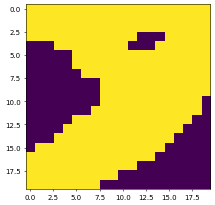

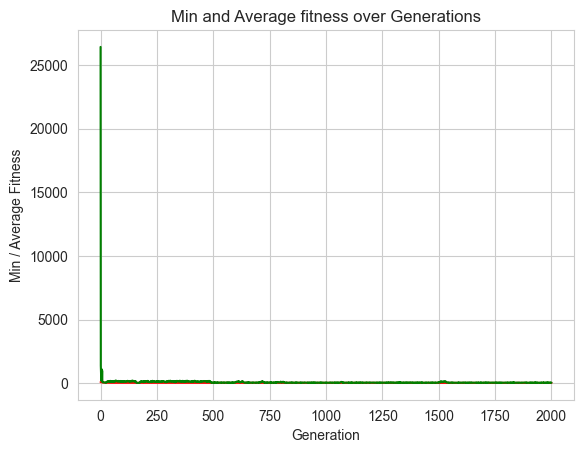

In [34]:
if __name__ == "__main__":
    start = time.time()
    top_ = main()
    end = time.time()


Final Cantilever beam design:


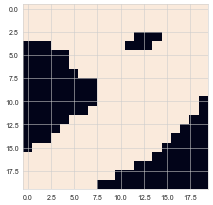

In [35]:
draw(top_)

### RL model

In [36]:
class Model:
    def __init__(self, x):
        self.flag_ = True
        self.n, self.m = x.shape
        self.actions_dic={} 
    
        k=0
        for i in range(self.n):
            for j in range(self.m):
                self.actions_dic[k]=(i,j)
                k+=1
        
    def action_space_(self, action, X):
        x,y=self.actions_dic[action]
        X[x][y]=1

In [37]:
class CantileverEnv(gymnasium.Env):
    
    metadata = {"render.modes": ["human"]}

    def __init__(self,x1,y1):
        super().__init__()
        self.x0=x1
        self.y0=y1
        
        DIM =  self.x0 * self.y0
        N_DISCRETE_ACTIONS = self.x0 * self.y0
        
        self.action_space = spaces.Discrete(N_DISCRETE_ACTIONS)
        self.observation_space = spaces.Box(low=np.array([-1e10 for x in range(DIM)]),
                                            high=np.array([1e10 for y in range(DIM)]),
                                            shape=(DIM,),
                                           dtype=np.float64)
        
        self.x = np.ones(( self.x0, self.y0))*1e-04
    
        self.M=Model(self.x)
        
        self.reward=0
        self.step_=0
        self.needs_reset = True
        self.ext_reward=0

        
    def step(self, action):
        
        self.M.action_space_(action, self.x)        
        self.step_+=1
               
        done=False
                  
        if self.step_ > self.x0 * self.y0:                    # to tune 
            done=True            
            
        if self.needs_reset:
            raise RuntimeError("Tried to step environment that needs reset")
            
        if done:
            self.needs_reset = True
                         
        
        return self.x.reshape(self.x.shape[0]*self.x.shape[1]), self.ext_reward, done, False, dict()

    def reset(self, seed=0):
                   
        self.x = np.ones((self.x0, self.y0))*1e-04

        self.reward=0
        self.needs_reset = False
        self.step_=0
        self.ext_reward=0

        return self.x.reshape(self.x.shape[0]*self.x.shape[1]),{}

    def render(self, mode="human"):
        pass   

    def close(self):
        pass

In [38]:
class SaveOnBestTrainingRewardCallback(BaseCallback):
    """
    Callback for saving a model (the check is done every ``check_freq`` steps)
    based on the training reward (in practice, we recommend using ``EvalCallback``).

    :param check_freq: (int)
    :param log_dir: (str) Path to the folder where the model will be saved.
      It must contains the file created by the ``Monitor`` wrapper.
    :param verbose: (int)
    """

    def __init__(self, check_freq: int, log_dir: str, verbose=1):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.log_dir = log_dir
        self.save_path = os.path.join(log_dir, "best_model")
        self.best_mean_reward = -np.inf

    def _init_callback(self) -> None:
        # Create folder if needed
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:
            
            
            
            # Retrieve training reward
            x, y = ts2xy(load_results(self.log_dir), "timesteps")

            if len(x) > 0:
                # Mean training reward over the last 100 episodes
                
                mean_reward = np.mean(y[-100:])
                
                if self.verbose > 0:
                    print(f"Num timesteps: {self.num_timesteps}")
                    print(
                        f"Best mean reward: {self.best_mean_reward:.2f} - Last mean reward per episode: {mean_reward:.2f}"
                    )

                # New best model, you could save the agent here
                if mean_reward > self.best_mean_reward:
                    self.best_mean_reward = mean_reward
                    # Example for saving best model
                    if self.verbose > 0:
                        print(f"Saving new best model to {self.save_path}.zip")
                    self.model.save(self.save_path)

        return True

In [39]:
def reconstruct_3d_structure(xy_plane, yz_plane, xz_plane):
    """
    Reconstructs a 3D structure from three 2D projections using extrusion and intersection.

    Parameters:
        xy_plane (ndarray): 2D binary array (X by Y) projection in XY plane.
        yz_plane (ndarray): 2D binary array (Y by Z) projection in YZ plane.
        xz_plane (ndarray): 2D binary array (X by Z) projection in XZ plane.

    Returns:
        volume (ndarray): 3D binary array (X by Y by Z) representing the reconstructed structure.
    """
    x_dim, y_dim = xy_plane.shape
    y_dim2, z_dim = yz_plane.shape
    x_dim2, z_dim2 = xz_plane.shape

    assert x_dim == x_dim2, "X dimensions mismatch between XY and XZ planes."
    assert y_dim == y_dim2, "Y dimensions mismatch between XY and YZ planes."
    assert z_dim == z_dim2, "Z dimensions mismatch between YZ and XZ planes."

    # Extrude XY along Z
    xy_extruded = np.repeat(xy_plane[:, :, np.newaxis], z_dim, axis=2)

    # Extrude YZ along X
    yz_extruded = np.repeat(yz_plane[np.newaxis, :, :], x_dim, axis=0)

    # Extrude XZ along Y
    xz_extruded = np.repeat(xz_plane[:, np.newaxis, :], y_dim, axis=1)

    # Intersect all three extrusions
    volume = xy_extruded & yz_extruded & xz_extruded

    return volume.astype(np.uint8)  # or bool, depending on your needs

In [40]:
def compute_single_reward(args_tuple):
    grid_data, action_slice, task_index, x0, y0 = args_tuple
    
    gr = deconstruct(grid_data, action_slice.reshape(x0//4, y0//4), task_index, x0, y0)
    constI = np.sum(gr) / (x0 * y0)

    if constI > 0.60:                     # to tune 
        args = get_args(*mbb_beam(rd=0))
        tmp, const = fast_stopt(args, gr)
        reward = 1/tmp
        
#         reward = 1/tmp + 1/calculate_smoothness_metric(gr.reshape(x0, y0))
#         if count_islands_dfs(gr) == 1:
#             reward *= 10

        return reward
    return 0.0  

In [41]:
class CrossRewardEnv(gymnasium.Env):
    def __init__(self):
        super().__init__()
        self.env0 = CantileverEnv(x0//4,y0//4)
        self.env1 = CantileverEnv(x0//4,y0//4)
        self.env2 = CantileverEnv(x0//4,y0//4)
        self.env3 = CantileverEnv(x0//4,y0//4)
        self.env4 = CantileverEnv(x0//4,y0//4)
        self.env5 = CantileverEnv(x0//4,y0//4)
        self.env6 = CantileverEnv(x0//4,y0//4)
        self.env7 = CantileverEnv(x0//4,y0//4)
        self.env8 = CantileverEnv(x0//4,y0//4)
        self.env9 = CantileverEnv(x0//4,y0//4)
        self.env10 = CantileverEnv(x0//4,y0//4)
        self.env11 = CantileverEnv(x0//4,y0//4)
        self.env12 = CantileverEnv(x0//4,y0//4)
        self.env13 = CantileverEnv(x0//4,y0//4)
        self.env14 = CantileverEnv(x0//4,y0//4)
        self.env15 = CantileverEnv(x0//4,y0//4)

        self.observation_space = spaces.Dict({
            'plane0': self.env0.observation_space,
            'plane1': self.env1.observation_space,
            'plane2': self.env2.observation_space,
            'plane3': self.env3.observation_space,
            'plane4': self.env4.observation_space,
            'plane5': self.env5.observation_space,
            'plane6': self.env6.observation_space,
            'plane7': self.env7.observation_space,
            'plane8': self.env8.observation_space,
            'plane9': self.env9.observation_space,
            'plane10': self.env10.observation_space,
            'plane11': self.env11.observation_space,
            'plane12': self.env12.observation_space,
            'plane13': self.env13.observation_space,
            'plane14': self.env14.observation_space,
            'plane15': self.env15.observation_space,
        })

        self.action_space = spaces.MultiDiscrete([(x0*y0)//16 for i in range(16)])
        self.step1_ = 0
        self.grid = np.where( top_ == 0, 1e-04, top_)      
        self.grid_glob = np.where( top_ == 0, 1e-04, top_)
        self.num_cores = 8
        self.x0=x0
        self.y0=y0

    def reset(self, seed=0):
        obs0, info0 = self.env0.reset()
        obs1, info1 = self.env1.reset()
        obs2, info2 = self.env2.reset()
        obs3, info3 = self.env3.reset()
        obs4, info4 = self.env4.reset()
        obs5, info5 = self.env5.reset()
        obs6, info6 = self.env6.reset()
        obs7, info7 = self.env7.reset()
        obs8, info8 = self.env8.reset()
        obs9, info9 = self.env9.reset()
        obs10, info10 = self.env10.reset()
        obs11, info11 = self.env11.reset()
        obs12, info12 = self.env12.reset()
        obs13, info13 = self.env13.reset()
        obs14, info14 = self.env14.reset()
        obs15, info15 = self.env15.reset()
        self.step1_=0
        self.grid_glob = np.where(top_ == 0, 1e-04, top_) 
        return {
            'plane0': obs0,
            'plane1': obs1,
            'plane2': obs2,
            'plane3': obs3,
            'plane4': obs4,
            'plane5': obs5,
            'plane6': obs6,
            'plane7': obs7,
            'plane8': obs8,
            'plane9': obs9,
            'plane10': obs10,
            'plane11': obs11,
            'plane12': obs12,
            'plane13': obs13,
            'plane14': obs14,
            'plane15': obs15,
        }, {
            'plane0': info0,
            'plane1': info1,
            'plane2': info2,
            'plane3': info3,
            'plane4': info4,
            'plane5': info5,
            'plane6': info6,
            'plane7': info7,
            'plane8': info8,
            'plane9': info9,
            'plane10': info10,
            'plane11': info11,
            'plane12': info12,
            'plane13': info13,
            'plane14': info14,
            'plane15': info15,
        }

    def step(self, action):
        a0 = action[0]
        a1 = action[1]
        a2 = action[2]
        a3 = action[3]
        a4 = action[4]
        a5 = action[5]
        a6 = action[6]
        a7 = action[7]
        a8 = action[8]
        a9 = action[9]
        a10 = action[10]
        a11 = action[11]
        a12 = action[12]
        a13 = action[13]
        a14 = action[14]
        a15 = action[15]
        
        
        obs0, r0, done0,_, info0 = self.env0.step(a0)
        obs1, r1, done1,_, info1 = self.env1.step(a1)
        obs2, r2, done2,_, info2 = self.env2.step(a2)
        obs3, r3, done3,_, info3 = self.env3.step(a3)
        obs4, r4, done4,_, info4 = self.env4.step(a4)
        obs5, r5, done5,_, info5 = self.env5.step(a5)
        obs6, r6, done6,_, info6 = self.env6.step(a6)
        obs7, r7, done7,_, info7 = self.env7.step(a7)
        obs8, r8, done8,_, info8 = self.env8.step(a8)
        obs9, r9, done9,_, info9 = self.env9.step(a9)
        obs10, r10, done10,_, info10 = self.env10.step(a10)
        obs11, r11, done11,_, info11 = self.env11.step(a11)
        obs12, r12, done12,_, info12 = self.env12.step(a12)
        obs13, r13, done13,_, info13 = self.env13.step(a13)
        obs14, r14, done14,_, info14 = self.env14.step(a14)
        obs15, r15, done15,_, info15 = self.env15.step(a15)
       
        OBS=[obs0,obs1,obs2,obs3,obs4,obs5,obs6,obs7,obs8,obs9,obs10,obs11,obs12,obs13,obs14,obs15]    
        RE =[self.env0.ext_reward,
             self.env1.ext_reward,
             self.env2.ext_reward,
             self.env3.ext_reward,
             self.env4.ext_reward,
             self.env5.ext_reward,
             self.env6.ext_reward,
             self.env7.ext_reward,
             self.env8.ext_reward,
             self.env9.ext_reward,
             self.env10.ext_reward,
             self.env11.ext_reward,
             self.env12.ext_reward,
             self.env13.ext_reward,
             self.env14.ext_reward,
             self.env15.ext_reward,
            ] 
        
        task_args = []
        for i in range(self.num_cores):
            task_args.append((self.grid, OBS[i], i, self.x0, self.y0))
            self.grid_glob = deconstruct(self.grid_glob, OBS[i].reshape(self.x0//4,self.y0//4), i, self.x0, self.y0)
            rewards_list1 = pool.map(compute_single_reward, task_args)

            
        for i in range(self.num_cores, 2*self.num_cores):
            task_args.append((self.grid, OBS[i], i, self.x0, self.y0))
            self.grid_glob = deconstruct(self.grid_glob, OBS[i].reshape(self.x0//4,self.y0//4), i, self.x0, self.y0)
            rewards_list2 = pool.map(compute_single_reward, task_args)
        
        CO = np.sum(self.grid_glob )/(x0 * y0)
     
        rewards_list = rewards_list1 + rewards_list2 
        
        for i in range(len(OBS)): 
            RE[i]=rewards_list[i] 
                            
        self.step1_+=1
        
        Do=(CO > 0.67)                     # to tune 
        done = (done0 or done1 or done2 or done3 or done4 or done5 or done6 or
        done7 or done8 or done9 or done10 or done11 or done12 or done13 or done14 or done15 or bool(Do))
        
        if CO > 0.60:                     # to tune 
            args_glob = get_args(*mbb_beam(rd=0))
            tmp_glob, const_glob = fast_stopt(args_glob, self.grid_glob)
            REW = 1/tmp_glob 
#             REW = 1/tmp_glob + 1/calculate_smoothness_metric(self.grid_glob.reshape(x0, y0))
#             if count_islands_dfs(self.grid_glob) == 1:
#                 REW *= 10
        else:
            REW = 0
        
        
        return {
            'plane0': obs0,
            'plane1': obs1,
            'plane2': obs2,
            'plane3': obs3,
            'plane4': obs4,
            'plane5': obs5,
            'plane6': obs6,
            'plane7': obs7,
            'plane8': obs8,
            'plane9': obs9,
            'plane10': obs10,
            'plane11': obs11,
            'plane12': obs12,
            'plane13': obs13,
            'plane14': obs14,
            'plane15': obs15,
        },  REW, done, False, {
            'plane0': info0,
            'plane1': info1,
            'plane2': info2,
            'plane3': info3,
            'plane4': info4,
            'plane5': info5,
            'plane6': info6,
            'plane7': info7,
            'plane8': info8,
            'plane9': info9,
            'plane10': info10,
            'plane11': info11,
            'plane12': info12,
            'plane13': info13,
            'plane14': info14,
            'plane15': info15,
        }

    def render(self, mode='human'):    
        pass

    def close(self):
        self.env0.close()
        self.env1.close()
        self.env2.close()
        self.env3.close()
        self.env4.close()
        self.env5.close()
        self.env6.close()
        self.env7.close()
        self.env8.close()
        self.env9.close()
        self.env10.close()
        self.env11.close()
        self.env12.close()
        self.env13.close()
        self.env14.close()
        self.env15.close()

### Training 

In [42]:
ts = 0.3e6

In [43]:
# Create log dir
log_dir = "/tmp/gym7_v3aleof1qaz/"
os.makedirs(log_dir, exist_ok=True)

In [44]:
callback = SaveOnBestTrainingRewardCallback(check_freq = 50_000, log_dir=log_dir)

In [45]:
env=CrossRewardEnv()
check_env(env)
env  = Monitor(env, log_dir)

In [ ]:
start = time.time()
model = PPO("MultiInputPolicy", env).learn(total_timesteps=ts, callback=callback)
end = time.time()  

Num timesteps: 50000
Best mean reward: -inf - Last mean reward per episode: 0.05
Saving new best model to /tmp/gym7_v3aleof1qaz/best_model.zip
Num timesteps: 100000
Best mean reward: 0.05 - Last mean reward per episode: 0.05
Saving new best model to /tmp/gym7_v3aleof1qaz/best_model.zip


In [ ]:
print('Total time taken: {} min'.format((end - start)/60))

### Inference

In [ ]:
def construct(obs_dict, env_idx=0):
    grid = np.zeros((x0, y0), dtype=int)
    for i in range(16):
        plane = obs_dict[i]['plane{}'.format(i)]  
        row_offset = (i // 4) * (x0 // 4)
        col_offset = (i % 4) * (x0 // 4)
        grid[row_offset:row_offset + x0//4, col_offset:col_offset + x0//4] = plane.reshape(x0//4, y0//4)
    return grid

In [ ]:
obs = env.reset()

In [ ]:
obs = obs[0]

In [ ]:
ans=[]
for i in range(1000):
    action, _states = model.predict(obs)
    obs, rewards, dones,_, infos = env.step(action)
    ans.append(obs)
    if dones:   
        break

In [ ]:
OBS = [ans[-1] for i in range(16)]

grid = construct(OBS)

In [ ]:
grid

In [ ]:
draw(grid)

In [ ]:
results_plotter.plot_results([log_dir], ts, results_plotter.X_TIMESTEPS, "CantileverEnv")

In [ ]:
obs = env.reset()

In [ ]:
obs = obs[0]

In [ ]:
model_best = PPO.load(log_dir + "best_model.zip", env = env)

In [ ]:
ans=[]
for i in range(1000):
    action, _states = model_best.predict(obs)
    obs, rewards, dones, _,infos = env.step(action)
    ans.append(obs)
    if dones:   
        break

In [ ]:
OBS = [ans[-1] for i in range(16)]
grid = construct(OBS)

In [ ]:
draw(grid)

In [ ]:
args = get_args(*mbb_beam(rd=0))
tmp, const = fast_stopt(args, grid.astype(float))

In [ ]:
tmp

In [ ]:
const

In [ ]:
grid

In [ ]:
arr = grid

In [ ]:
# 1. Convert Matrix to Point Cloud
# np.argwhere finds indices where value is 1
points = np.argwhere(arr == 1)

# 2. Build the Alpha Complex
# This reconstructs the topological structure from the discrete points
alpha_complex = gd.AlphaComplex(points=points)
simplex_tree = alpha_complex.create_simplex_tree()

# 3. Visualization
plt.figure(figsize=(5, 5))

# Plot the original matrix points
plt.scatter(points[:, 1], points[:, 0], c='red', label='Matrix Points (1s)')

# Reconstruct and plot the edges (1-simplices)
# Adjust alpha_threshold to "connect" points at different distances
alpha_threshold = 3
for simplex, filtration in simplex_tree.get_skeleton(1):
    if len(simplex) == 2 and filtration < alpha_threshold:
        p1, p2 = points[simplex[0]], points[simplex[1]]
        # Note: argwhere returns (row, col), so we plot (col, row) for (x, y)
        plt.plot([p1[1], p2[1]], [p1[0], p2[0]], 'b-', alpha=0.6)

plt.gca().invert_yaxis() # Match matrix coordinate system (top-down)
plt.title("Topology Reconstructed from Binary Matrix")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# 4. Extract Topological Invariants
persistence = simplex_tree.persistence()
print("Topological Features found:")
for dim, (birth, death) in persistence:
    feature_type = "Component" if dim == 0 else "Hole/Loop"
    print(f"{feature_type} exists from radius {birth} to {death}")

In [ ]:
pool.close()   
pool.join()